# Lifestyle-Based Taste Preference Prediction Dataset (KNN- Classification)

# Problem Statement
 - The objective of this project is to analyze the impact of lifestyle and environmental factors on food taste preferences and develop a machine learning model that can accurately predict an individual's preferred taste category (Salty, Sweet, Sour, or Spicy) based on the available features.

# Dataset Structure
- The dataset contains information about individuals' age, sleep cycle patterns, exercise habits, climate zones, historical cuisine exposure, and preferred taste preferences. The goal is to analyze how these factors influence taste choices and build a predictive classification model.
- Total Rows           : 10000
- Total Columns        : 6
- Independent Variables:
1. Age
2. Sleep Cycle
3. Exercise Habits
4. Climate Zone
5. Historical Cuisine Exposure
- Target Column        : Preferred Taste
- Problem Type         : Classification Problem
- Model Used           : KNN Classifier

# Importing Libraries

In [160]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Dataset Importing

In [119]:
df=pd.read_csv('FlavorSense.csv')
df

,age,sleep_cycle,exercise_habits,climate_zone,historical_cuisine_exposure,preferred_taste
0,56.0,Irregular,Heavy,Temperate,NaN,Salty
1,NaN,Night Owl,Heavy,Temperate,Asian,Sweet
2,46.0,Night Owl,Heavy,Cold,Mixed,Sour
3,32.0,Early Bird,Heavy,Cold,Mediterranean,Salty
4,60.0,Night Owl,Moderate,Dry,Mediterranean,Sour
...,...,...,...,...,...,...
9995,55.0,Irregular,Light,Cold,Mixed,Sour
9996,51.0,Early Bird,Light,Dry,Asian,Sweet
9997,57.0,Early Bird,NaN,Cold,Mediterranean,Salty
9998,64.0,Irregular,Light,Tropical,Mixed,Sweet


# Data Understanding

In [120]:
df.head()

,age,sleep_cycle,exercise_habits,climate_zone,historical_cuisine_exposure,preferred_taste
0,56.0,Irregular,Heavy,Temperate,NaN,Salty
1,NaN,Night Owl,Heavy,Temperate,Asian,Sweet
2,46.0,Night Owl,Heavy,Cold,Mixed,Sour
3,32.0,Early Bird,Heavy,Cold,Mediterranean,Salty
4,60.0,Night Owl,Moderate,Dry,Mediterranean,Sour


In [121]:
df.tail()

,age,sleep_cycle,exercise_habits,climate_zone,historical_cuisine_exposure,preferred_taste
9995,55.0,Irregular,Light,Cold,Mixed,Sour
9996,51.0,Early Bird,Light,Dry,Asian,Sweet
9997,57.0,Early Bird,NaN,Cold,Mediterranean,Salty
9998,64.0,Irregular,Light,Tropical,Mixed,Sweet
9999,32.0,Early Bird,Heavy,Tropical,Mediterranean,Sour


In [122]:
print(f'Number of rows:{df.shape[0]}')
print(f'Number oF columns: {df.shape[1]}')

Number of rows:10000
Number oF columns: 6


In [123]:
df.describe()

,age
count,9032.000000
mean,43.552702
std,14.889327
min,18.000000
25%,31.000000
50%,43.000000
75%,56.000000
max,69.000000


In [124]:
df.describe(include=object)

,sleep_cycle,exercise_habits,climate_zone,historical_cuisine_exposure,preferred_taste
count,9316,9196,9467,9346,10000
unique,3,3,4,3,4
top,Early Bird,Moderate,Tropical,Mediterranean,Sweet
freq,3149,3106,2443,3157,4367


In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          9032 non-null   float64
 1   sleep_cycle                  9316 non-null   object 
 2   exercise_habits              9196 non-null   object 
 3   climate_zone                 9467 non-null   object 
 4   historical_cuisine_exposure  9346 non-null   object 
 5   preferred_taste              10000 non-null  object 
dtypes: float64(1), object(5)
memory usage: 468.9+ KB


In [126]:
df.dtypes

age                            float64
sleep_cycle                     object
exercise_habits                 object
climate_zone                    object
historical_cuisine_exposure     object
preferred_taste                 object
dtype: object

# Data Quality Check

In [127]:
df.duplicated().sum()

np.int64(3676)

In [128]:
df.drop_duplicates(inplace=True)

In [129]:
df.isna().sum()

age                            335
sleep_cycle                    634
exercise_habits                731
climate_zone                   483
historical_cuisine_exposure    597
preferred_taste                  0
dtype: int64

In [130]:
for i in df.columns:
    print(f'Missing values in {i} is {(df[i].isna().sum()/6324)*100} %')

Missing values in age is 5.297280202403542 %
Missing values in sleep_cycle is 10.025300442757748 %
Missing values in exercise_habits is 11.559139784946236 %
Missing values in climate_zone is 7.637571157495255 %
Missing values in historical_cuisine_exposure is 9.44022770398482 %
Missing values in preferred_taste is 0.0 %


In [131]:
#Dealing with missing values for int columns with Average of columns because their is no OUTLIERS present in age columns
si=SimpleImputer(strategy='mean')
df['age']=si.fit_transform(df[['age']])

In [132]:
##Dealing with missing values for object columns with Mode of columns
si=SimpleImputer(strategy='most_frequent')
df[['sleep_cycle','exercise_habits','climate_zone','historical_cuisine_exposure']]= si.fit_transform(
    df[['sleep_cycle','exercise_habits','climate_zone','historical_cuisine_exposure']]
)

In [133]:
df.isna().sum()

age                            0
sleep_cycle                    0
exercise_habits                0
climate_zone                   0
historical_cuisine_exposure    0
preferred_taste                0
dtype: int64

# Exploratory Data Analysis

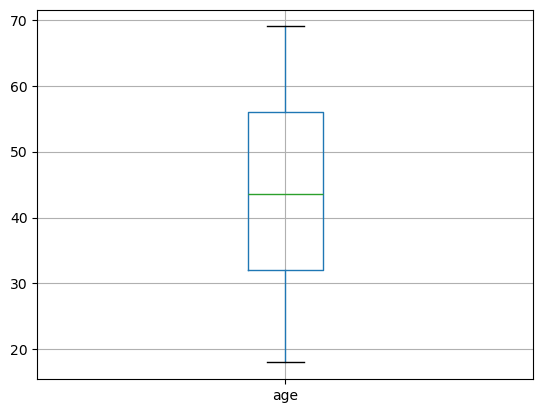

In [134]:
df.boxplot()
plt.show()

In [135]:
df.groupby('exercise_habits')['age'].mean().sort_values(ascending=True)

exercise_habits
Light       43.563150
Moderate    43.603029
Heavy       43.650517
Name: age, dtype: float64

In [136]:
df.groupby('historical_cuisine_exposure')['age'].mean().sort_values(ascending=True)

historical_cuisine_exposure
Asian            43.452678
Mixed            43.593940
Mediterranean    43.725507
Name: age, dtype: float64

In [137]:
df.groupby(['preferred_taste', 'exercise_habits'])['age'].mean().sort_values(ascending=True)

preferred_taste  exercise_habits
Spicy            Heavy              24.418646
                 Moderate           28.289457
                 Light              32.523217
Sweet            Heavy              37.941583
                 Moderate           38.986989
                 Light              42.481659
Sour             Heavy              44.478156
                 Moderate           44.842497
Salty            Moderate           49.487357
Sour             Light              49.650845
Salty            Heavy              49.886449
Name: age, dtype: float64

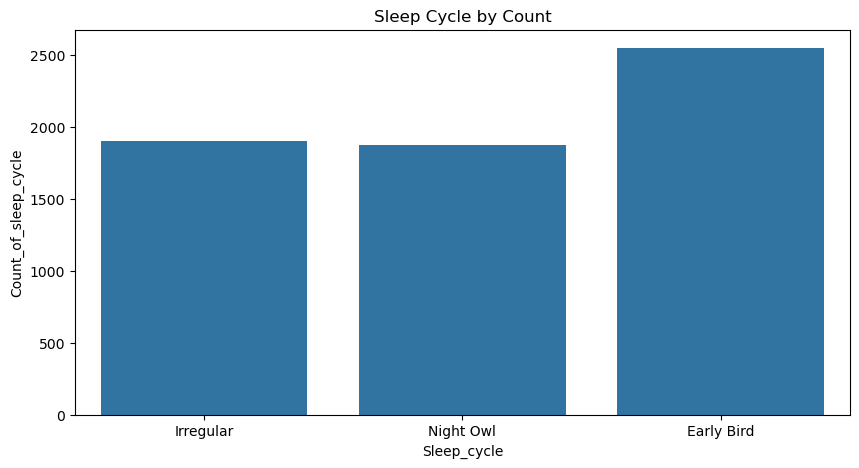

In [138]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['sleep_cycle'],data=df)
plt.xlabel('Sleep_cycle')
plt.ylabel('Count_of_sleep_cycle')
plt.title('Sleep Cycle by Count')
plt.show()


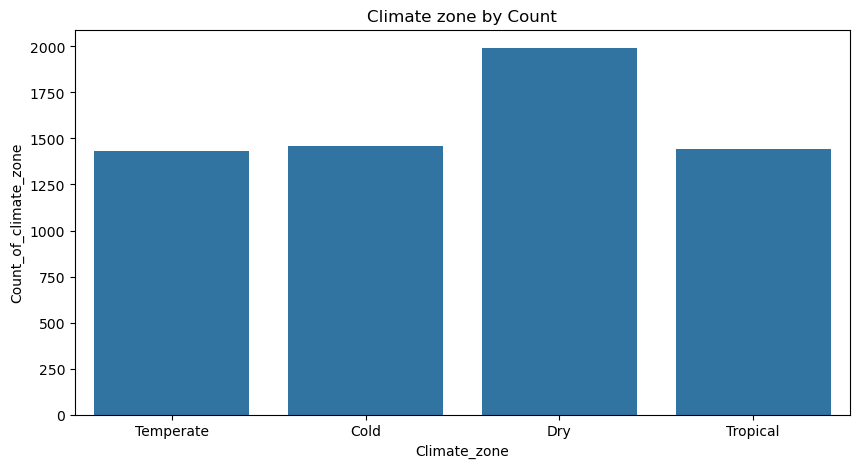

In [139]:
plt.figure(figsize=(10,5))
sns.countplot(x=df['climate_zone'],data=df)
plt.xlabel('Climate_zone')
plt.ylabel('Count_of_climate_zone')
plt.title('Climate zone by Count')
plt.show()


# Encoding

In [140]:
df.head()

,age,sleep_cycle,exercise_habits,climate_zone,historical_cuisine_exposure,preferred_taste
0,56.000000,Irregular,Heavy,Temperate,Mediterranean,Salty
1,43.605109,Night Owl,Heavy,Temperate,Asian,Sweet
2,46.000000,Night Owl,Heavy,Cold,Mixed,Sour
3,32.000000,Early Bird,Heavy,Cold,Mediterranean,Salty
4,60.000000,Night Owl,Moderate,Dry,Mediterranean,Sour


In [141]:
for i in df.select_dtypes(include='object').columns:
    print(i)
    print(df[i].unique())
    print('-'*50)

sleep_cycle
['Irregular' 'Night Owl' 'Early Bird']
--------------------------------------------------
exercise_habits
['Heavy' 'Moderate' 'Light']
--------------------------------------------------
climate_zone
['Temperate' 'Cold' 'Dry' 'Tropical']
--------------------------------------------------
historical_cuisine_exposure
['Mediterranean' 'Asian' 'Mixed']
--------------------------------------------------
preferred_taste
['Salty' 'Sweet' 'Sour' 'Spicy']
--------------------------------------------------


# Ordinal Encoding

In [142]:
df['sleep_cycle']=df['sleep_cycle'].map( {
    'Early Bird': 0,
    'Irregular': 1,
    'Night Owl': 2
})

In [143]:
df['exercise_habits']=df['exercise_habits'].map({
     'Light': 0,
    'Moderate': 1,
    'Heavy': 2
})

# One-Hot encoding

In [144]:
df=pd.get_dummies(data=df,columns=['climate_zone','historical_cuisine_exposure'],dtype=int)

# Label Encoding

In [145]:
li=LabelEncoder()
df['preferred_taste']=li.fit_transform(df['preferred_taste'])

In [146]:
df.head()

,age,sleep_cycle,exercise_habits,preferred_taste,climate_zone_Cold,climate_zone_Dry,climate_zone_Temperate,climate_zone_Tropical,historical_cuisine_exposure_Asian,historical_cuisine_exposure_Mediterranean,historical_cuisine_exposure_Mixed
0,56.000000,1,2,0,0,0,1,0,0,1,0
1,43.605109,2,2,3,0,0,1,0,1,0,0
2,46.000000,2,2,1,1,0,0,0,0,0,1
3,32.000000,0,2,0,1,0,0,0,0,1,0
4,60.000000,2,1,1,0,1,0,0,0,1,0


# Defining x and y

In [147]:
X=df.drop(columns='preferred_taste')
y=df['preferred_taste']

# Scaling For X

In [148]:
si=StandardScaler()
scaled_data = si.fit_transform(df)
scaled_data

array([[ 0.85175895,  0.12871095,  1.31189061, ..., -0.64574305,
         1.22256883, -0.66225413],
       [ 0.        ,  1.3345895 ,  1.31189061, ...,  1.54860357,
        -0.81794985, -0.66225413],
       [ 0.16457342,  1.3345895 ,  1.31189061, ..., -0.64574305,
        -0.81794985,  1.50999437],
       ...,
       [ 0.7830404 ,  0.12871095, -1.3032067 , ..., -0.64574305,
        -0.81794985,  1.50999437],
       [ 0.9204775 , -1.07716761,  0.00434195, ..., -0.64574305,
         1.22256883, -0.66225413],
       [ 1.40150738,  0.12871095, -1.3032067 , ..., -0.64574305,
        -0.81794985,  1.50999437]], shape=(6324, 11))

# Train-Test Split

In [149]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Finding best K Value

In [161]:
train_accuracy=[]
test_accuracy=[]
for i in range(2,20):
    kn=KNeighborsClassifier(n_neighbors=i)
    kn.fit(x_train,y_train)
    train_accuracy.append(kn.score(x_train,y_train))
    test_accuracy.append(kn.score(x_test,y_test))

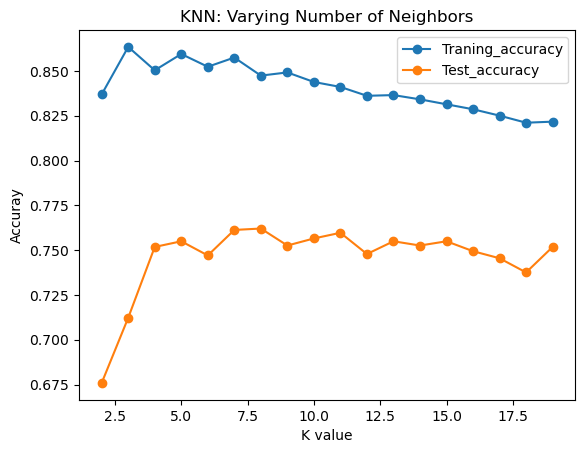

In [162]:
plt.plot(range(2,20),train_accuracy,label='Traning_accuracy',marker='o')
plt.plot(range(2,20),test_accuracy,label='Test_accuracy',marker='o')
plt.xlabel('K value')
plt.ylabel('Accuray')
plt.title('KNN: Varying Number of Neighbors')
plt.legend()
plt.show()

# Final Model Building

In [171]:
kn=KNeighborsClassifier(n_neighbors=8)
kn.fit(x_train,y_train)
y_pred=kn.predict(x_test)
y_pred

array([0, 1, 1, ..., 0, 0, 3], shape=(1265,))

# Evaluation

In [172]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.73      0.85      0.79       230
           1       0.71      0.78      0.74       468
           2       1.00      0.16      0.28        50
           3       0.83      0.77      0.80       517

    accuracy                           0.76      1265
   macro avg       0.82      0.64      0.65      1265
weighted avg       0.77      0.76      0.75      1265



In [173]:
print(f'Traning Accuracy: {kn.score(x_train,y_train)}')
print(f'Testing Accuracy: {kn.score(x_test,y_test)}')

Traning Accuracy: 0.8474006720695789
Testing Accuracy: 0.7620553359683795


### Conclusion

The K-Nearest Neighbors (KNN) Classifier was developed to predict an individual's preferred taste category (Salty, Sweet, Sour, or Spicy) using features such as age, sleep cycle, exercise habits, climate zone, and historical cuisine exposure.

The model achieved an **overall testing accuracy of 76%**, indicating that it correctly classified taste preferences for the majority of individuals. The training accuracy was slightly higher than the testing accuracy, suggesting that the model generalizes reasonably well to unseen data with limited overfitting.

The classification report shows strong performance for most classes:

* **Class 0:** Precision = 73%, Recall = 85%, F1-Score = 79%
* **Class 1:** Precision = 71%, Recall = 78%, F1-Score = 74%
* **Class 3:** Precision = 83%, Recall = 77%, F1-Score = 80%

However, **Class 2** had a low recall of **16%**, indicating that the model struggled to correctly identify this taste category. This is likely due to the smaller number of samples in that class (**support = 50**) compared to the others, causing class imbalance.

### Final Result

* **Training Accuracy:** (your printed value)
* **Testing Accuracy:** 76%
* **Weighted F1-Score:** 75%
* **Macro F1-Score:** 65%

The KNN Classifier demonstrates good overall performance in predicting taste preferences, achieving **76% accuracy**. While the model performs well for most taste categories, further improvements can be made by addressing class imbalance, tuning hyperparameters, or exploring advanced classification algorithms such as Random Forest, XGBoost, or Gradient Boosting.

✅ **The model is suitable as a baseline classification model for predicting food taste preferences based on lifestyle and environmental factors.**
